In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

data = sio.loadmat('HW07_Problem3.mat')


print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'samples'])


# 3.1

In [8]:
d = data['samples']
Phi = d[0,:]
h = d[1,:]
sigma2_0 = d[2,:]

N = len(Phi)
print("Number of samples:", N)

Number of samples: 100000


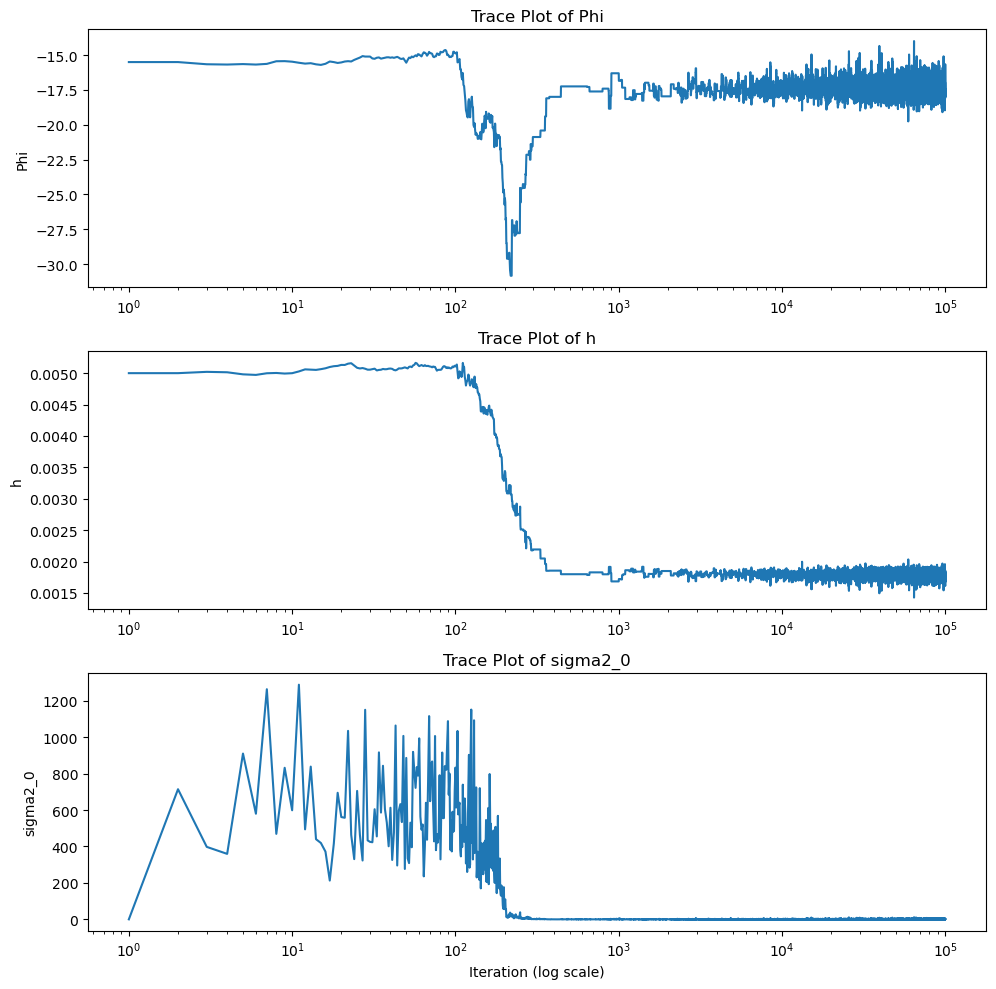

In [ ]:
iterations = np.arange(1, N+1)

fig, axs = plt.subplots(3,1, figsize=(10,10))

axs[0].plot(iterations, Phi)
axs[0].set_xscale('log')
axs[0].set_title('Trace Plot of Phi')
axs[0].set_ylabel('Phi')

axs[1].plot(iterations, h)
axs[1].set_xscale('log')
axs[1].set_title('Trace Plot of h')
axs[1].set_ylabel('h')

axs[2].plot(iterations, sigma2_0)
axs[2].set_xscale('log')
axs[2].set_title('Trace Plot of sigma2_0')
axs[2].set_ylabel('sigma2_0')
axs[2].set_xlabel('Sample Number (log scale)')

plt.tight_layout()
plt.show()

In [19]:
min(sigma2_0)

np.float64(0.11234226941138074)

Ideally, after burn-in, we expect a chain to fluctuate around a somewhat constant level. A good mixing means there is rapid movement by the chain (the chain must explore the parameter space not get stuck in one region). Near/after 300 samples, we see the trace plots for $\Phi$ and $h$ to relatively stabilize; they still move/appear like a thick band of noise, but there is no structural shifts or long-term trends (which are indicative of poor convergence). During the burn-in phase, the chain is still transitioning from the initial guess toward the region of high posterior probability. Early in the chain, the prior and initial parameter values influence the samples more strongly, particularly since the observation noise is initially large. As the chain progresses, the estimate of the noise variance decreases, which increases the influence of the data in the likelihood. As a result, the parameters $\Phi$ and h shift toward values that better explain the observations, after which the chain begins sampling from the stationary posterior distribution.

Meanwhile, the noise varaicne should have a trace plot that is a positive, stationary, moderately fluctuating band around a constant value. If the data noise goes to approximately 0, the likelihood becomes infinitely high and the model tries to perfectly interpolate data (the chain can freeze, or the model is overfitting with poor mixing). If the trace is almost flat, the posterior must be extremely concentrated or the chain is no longer mixing in a specific direction.

# 3.2

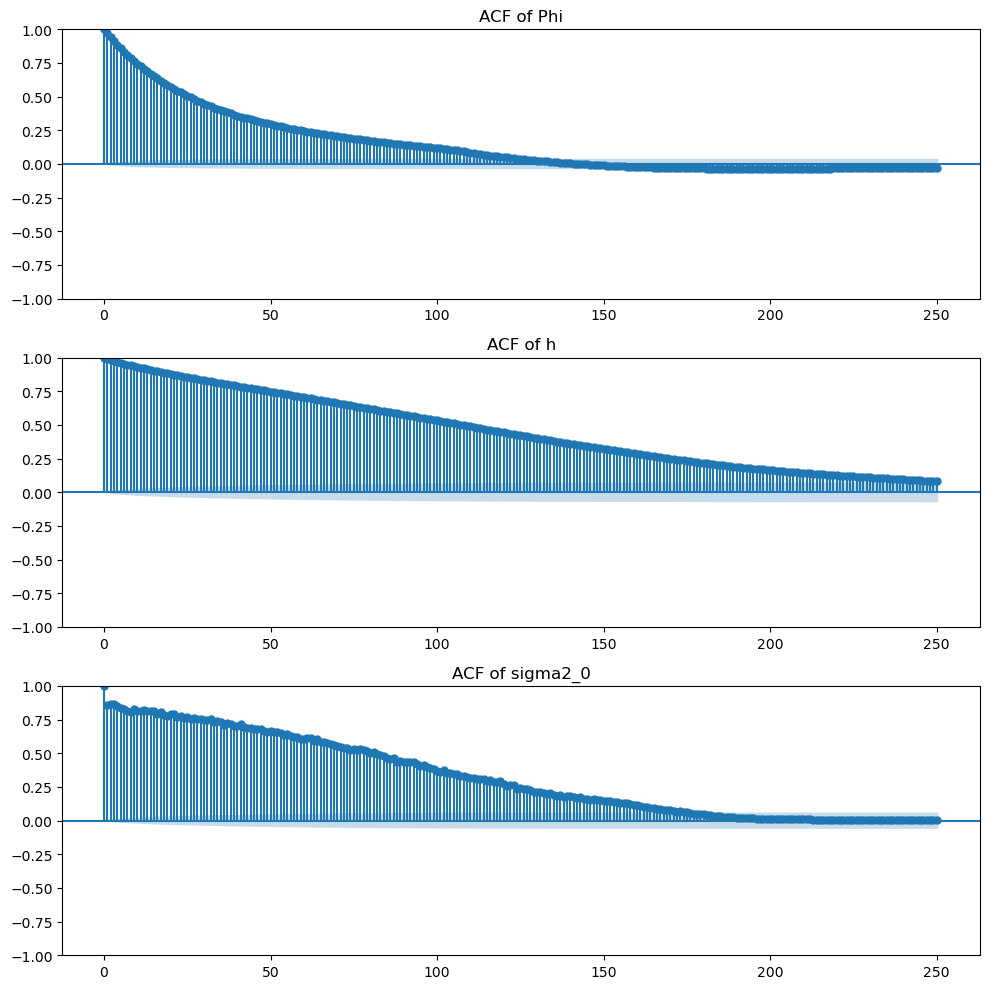

In [18]:
fig, axs = plt.subplots(3,1, figsize=(10,10))
lag = 250
plot_acf(Phi, lags=lag, ax=axs[0])
axs[0].set_title("ACF of Phi")

plot_acf(h, lags=lag, ax=axs[1])
axs[1].set_title("ACF of h")

plot_acf(sigma2_0, lags=lag, ax=axs[2])
axs[2].set_title("ACF of sigma2_0")

plt.tight_layout()
plt.show()

The ACF typically starts at 1 at lag 0 (by definition) and then decays as the lag increases. In an ideal setting where samples are independent draws from the target posterior distribution, the autocorrelation would drop immediately to approximately zero after lag 0. However, in practice—particularly when samples are generated using MCMC methods—the decay is gradual. In the plotted correlogram, the autocorrelation for 
$\Phi$ drops at a quadratic (?) rate (greater than linear) and the ACF is approximately 0 by sample 130. 

The ACF for $\Phi$ also exhibits slight negative values at large lags (>130) and displays a mild oscillatory pattern around zero. This behavior suggests that successive draws of $\Phi$ are not only positively correlated at short lags but may also exhibit small alternating dependence at intermediate lags. Such oscillations commonly arise in MCMC samples when the chain slightly over-corrects from one iteration to the next, producing small negative correlations before stabilizing. In well-behaved chains, these oscillations should decay rapidly toward zero as the lag increases. The presence of small negative autocorrelations is not inherently problematic; mild oscillation around zero can indicate reasonably efficient mixing, since the chain is not persistently drifting in one direction. Ideally, the ACF would drop immediately to zero for all nonzero lags, reflecting independent draws. However, in practical MCMC settings, slight oscillatory behavior and small negative values are expected and acceptable provided they diminish quickly and do not persist over large lags. If the oscillations remain significant across many lags, this would suggest stronger dependence and reduced effective sample size. In this case, the slight and decaying oscillatory pattern indicates moderate serial dependence but overall stable convergence behavior.

h decreases steadily but remains positive for >250 before slowly, linearly (?) approaching zero. This indicates moderate/high serial dependence in the chain. In general, if the decay is relatively quick (e.g., near zero by lag 20–40), the chain is mixing reasonably well. If instead the decay is slow and persistent across many lags, this suggests stronger dependence and a lower effective sample size: longer chains may be required for accurate posterior inference.

For $\sigma_2^2$, the autocorrelation behavior depends on how efficiently this variance parameter is sampled. If the sampler updates it using a conjugate or well-tuned step, the ACF may decay relatively quickly. However, variance parameters often exhibit moderate persistence, so the correlogram shows a noticeable but gradually declining positive correlation across lags. As with the other parameters, convergence toward zero at larger lags indicates that long-run independence is being approached.

# 3.3
The trace plots reveal distinct behavioral patterns for each parameter during the MCMC simulation. The $\Phi$ trace plot exhibits an interesting pattern where it initially drops, then rises with an inverted spike before stabilizing. This inverted spike typically indicates a region of low posterior probability that the chain temporarily visited before finding the main mode of the distribution. The $h$ trace plot shows a sudden drop followed by stabilization, suggesting the chain moved from a region of lower probability to the high-probability region of the posterior. Similarly, the $\sigma^2_0$ trace plot demonstrates a sharp decline before leveling off, reflecting the chain's transition from its initial value to the region of high posterior density for the error variance parameter.

Based on these trace plots, the approximate burn-in period appears to be around 300 iterations. This is the point where all three parameters stop exhibiting systematic trends and begin fluctuating around stable values. The burn-in period represents the phase where the Markov chain is moving from its starting point toward the high-probability region of the posterior distribution. During this phase, the samples are not representative of the target posterior distribution and should be discarded for subsequent inference.

At the point of burn-in, the chain has successfully navigated from the initial parameter values to the region of high posterior probability. This transition is marked by the parameters settling into their typical posterior ranges. For $\Phi$ and $h$, this means finding the parameter values that best explain the observed data given the model structure. For $\sigma^2_0$, burn-in represents the chain learning the appropriate scale of the observation error from the data. 

The autocorrelation function provides insight into the mixing efficiency of the chain. After burn-in, the autocorrelation decays reasonably quickly, indicating that the chain is exploring the parameter space effectively. The combination of Adaptive Metropolis and Delayed Rejection in the DRAM algorithm helps achieve this by learning the covariance structure of the target distribution and providing opportunities to accept states that might otherwise be rejected. The relatively rapid decay of autocorrelation suggests that the effective sample size is adequate for reliable posterior inference, despite the inherent correlation in MCMC samples.

The MCMC estimator demonstrates satisfactory performance overall. The chain converges to the stationary distribution within a reasonable number of iterations, and the post-burn-in samples appear to be exploring the posterior distribution appropriately. The different behaviors observed in the trace plots reflect the chain's ability to move through the parameter space and find the regions of high posterior probability. The Adaptive Metropolis component has clearly learned an effective proposal covariance, while the Delayed Rejection component has helped maintain good acceptance rates without sacrificing exploration efficiency.

# 3.4

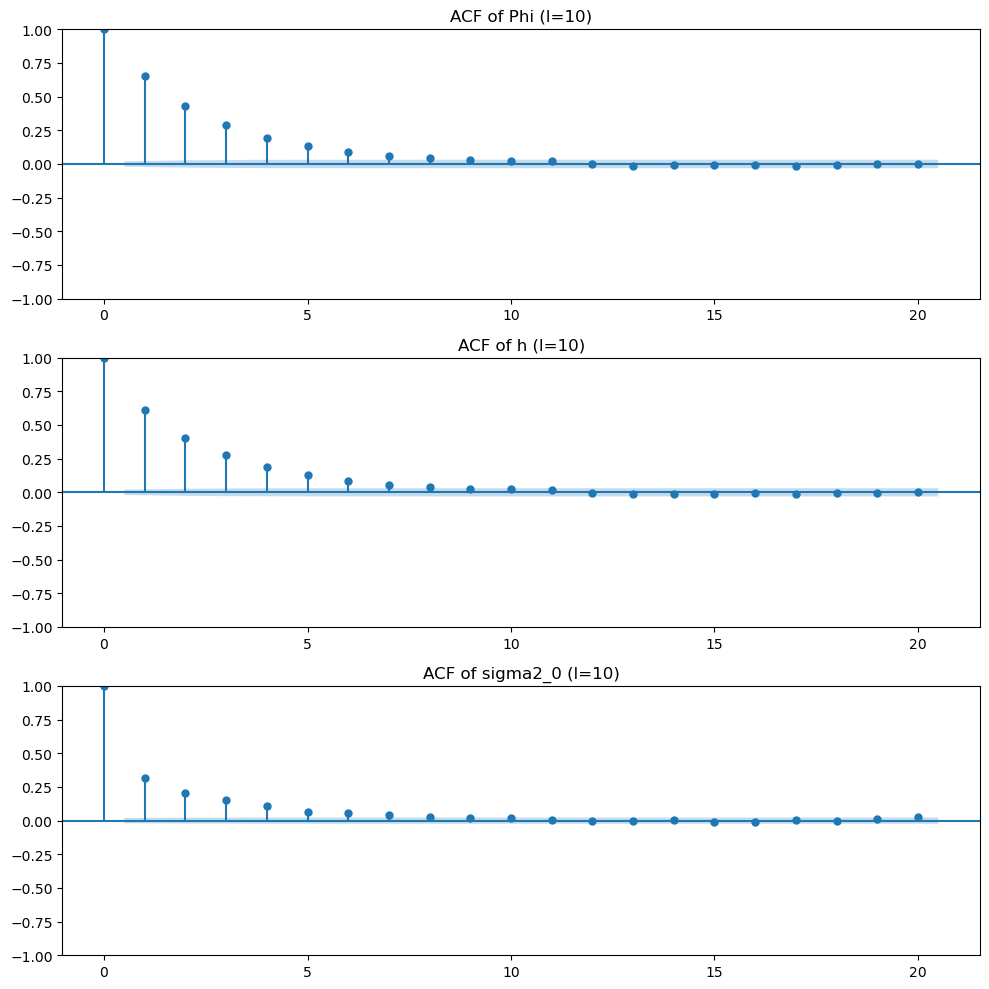

In [15]:
burn = 3000
l = 10

Phi_sub = Phi[burn::l]
h_sub = h[burn::l]
sigma_sub = sigma2_0[burn::l]

fig, axs = plt.subplots(3,1, figsize=(10,10))
lag = 20
plot_acf(Phi_sub, lags=lag, ax=axs[0])
axs[0].set_title("ACF of Phi (l=10)")

plot_acf(h_sub, lags=lag, ax=axs[1])
axs[1].set_title("ACF of h (l=10)")

plot_acf(sigma_sub, lags=lag, ax=axs[2])
axs[2].set_title("ACF of sigma2_0 (l=10)")

plt.tight_layout()
plt.show()

The ACF drops to 0 much quicker than when the stride length = 1 (e.g., no samples are trimmed/postprocessed). Selecting every $l^{th}$ sample of the chain (obviously) decreases the correlation between samples. 

# 3.5

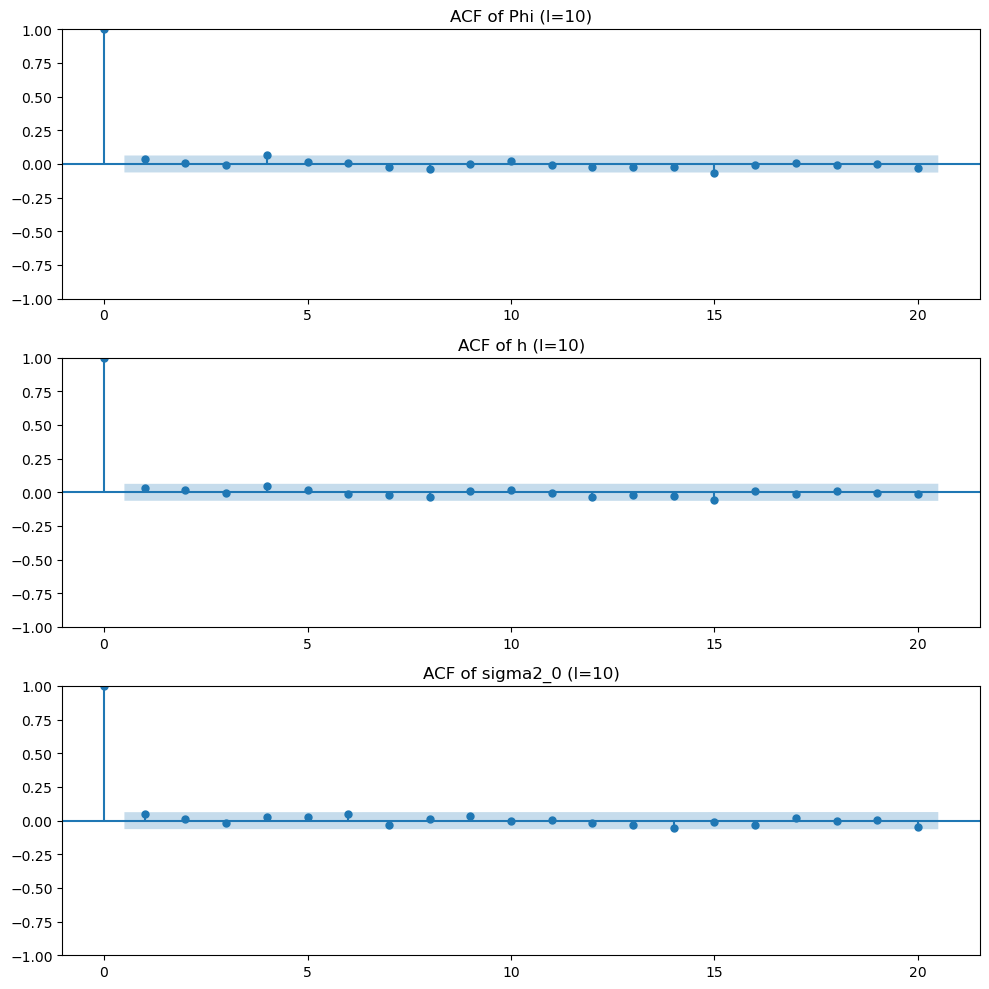

In [16]:
burn = 3000
l = 100

Phi_sub = Phi[burn::l]
h_sub = h[burn::l]
sigma_sub = sigma2_0[burn::l]

fig, axs = plt.subplots(3,1, figsize=(10,10))
lag = 20
plot_acf(Phi_sub, lags=lag, ax=axs[0])
axs[0].set_title("ACF of Phi (l=10)")

plot_acf(h_sub, lags=lag, ax=axs[1])
axs[1].set_title("ACF of h (l=10)")

plot_acf(sigma_sub, lags=lag, ax=axs[2])
axs[2].set_title("ACF of sigma2_0 (l=10)")

plt.tight_layout()
plt.show()

With $l = 100$, the ACF immediately drops to near 0 after the first sample (which is at 1, since the first sample is completely correlated with itself).  This indicates that samples separated by 100 iterations are essentially uncorrelated for all practical purposes.

The progression from the full chain to l = 10 to l = 100 shows a consistent pattern: as the stride length increases, the autocorrelation decreases monotonically. With l = 100, even at lag 1 (which represents a separation of 100 original iterations), the correlation has effectively vanished. This is consistent with the expectation that thinning the chain reduces the dependence between retained samples, and the effect becomes more pronounced as the thinning interval increases.

For all three parameters ($\Phi$, $h$, and $\sigma_0^2$), the ACF with l = 100 shows no significant correlation structure. Any remaining correlations are well within the confidence bands that would indicate statistical significance, meaning they are indistinguishable from zero given the finite sample size.

# 3.6
Based on the observed autocorrelation patterns, a stride length of $l \approx$ 50 would be appropriate to obtain nearly-independent samples from the posterior distribution. This recommendation is supported by several considerations:

First, examining the ACF for the full chain, the autocorrelation decays to near-zero levels by around lag 30-40 for all parameters. This indicates that the underlying Markov chain has a relatively short correlation time, meaning that samples become effectively independent after approximately 30-40 iterations. A conservative choice of $l$ = 50 ensures that we are safely beyond this correlation length.

Second, the progression from $l$ = 10 to $l$ = 100 shows diminishing returns. While $l$ = 10 still shows some residual correlation (particularly at the first few lags), $l$ = 50 would fall comfortably in the region where the ACF has already decayed to negligible levels. There is little practical benefit to using $l$ = 100 over $l$ = 50, as both produce effectively independent samples, but $l$ = 50 retains twice as many samples for posterior inference.

Third, the choice of $l$ = 50 balances the trade-off between sample independence and sample size. Thinning the chain too aggressively ($l$ = 100 or higher) discards potentially useful information without meaningful improvement in independence, since the samples were already effectively independent at shorter lags. The goal of thinning is not to achieve perfect independence (which is impossible with finite samples), but rather to reduce autocorrelation to a level where it does not materially affect inference.

A confirmatory ACF plot with $l$ = 50 should show that the autocorrelation at all positive lags is essentially zero, with any minor fluctuations falling well within the expected sampling variability. This confirms that samples retained every 50 iterations can be treated as approximately independent for the purposes of posterior summarization, credible interval construction, and density estimation.